# COVID Insurance Coverage Analysis

This notebook rebuilds the COVID-positive cohort, computes coverage metrics from claim-linked positive-test encounters, and renders the key figures and results inline.

## Setup

This cell imports libraries, defines colors and constants, and resolves the project root in a notebook-friendly way.

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))

import matplotlib
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
else:
    matplotlib.use("Agg")

import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Markdown, display


DATA_DIR = ROOT / "data"

RACE_ORDER = ["White", "Black", "Asian", "Native/Other"]
BURDEN_ORDER = ["0", "1", "2+"]
RACE_COLORS = {
    "White": "#4C78A8",
    "Black": "#F58518",
    "Asian": "#54A24B",
    "Native/Other": "#B279A2",
}
BURDEN_COLORS = {
    "0": "#4C78A8",
    "1": "#ECA02C",
    "2+": "#E45756",
}
HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "coverage_heatmap",
    ["#F4EAD5", "#74A57F", "#1D5C63"],
)
GAP_CMAP = LinearSegmentedColormap.from_list(
    "county_gap",
    ["#F6E7CB", "#F4A261", "#9A031E"],
)
COMORBIDITY_PATTERNS = {
    "Hyperlipidemia": r"hyperlipidemia",
    "Anemia": r"anemia",
    "Asthma": r"asthma",
    "Heart failure": r"heart failure",
    "Cancer": r"cancer|malignant|neoplasm",
    "Dementia": r"alzheimer|dementia",
    "Arthritis/pain": r"osteoarthritis|chronic pain|fibromyalgia",
    "Migraine": r"migraine",
    "Seizure disorder": r"seizure",
}


## Utility Functions

These helpers support shared summaries, confidence intervals, and grouped effect estimates.

In [2]:
def set_plot_style():
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams["figure.facecolor"] = "#FCFAF7"
    plt.rcParams["axes.facecolor"] = "#FCFAF7"
    plt.rcParams["savefig.facecolor"] = "#FCFAF7"
    plt.rcParams["axes.edgecolor"] = "#D7D2CB"
    plt.rcParams["grid.color"] = "#E6E1D8"
    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False


def proportion_ci(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    p = series["mortality_rate"]
    n = series["n"]
    se = np.sqrt(np.clip(p * (1 - p) / n, 0, None))
    return p - 1.96 * se, p + 1.96 * se


def group_summary(
    frame: pd.DataFrame, group_cols: list[str], value_col: str
) -> pd.DataFrame:
    grouped = (
        frame.groupby(group_cols, dropna=False, observed=False)
        .agg(
            n=("PATIENT", "size"),
            mean_coverage=(value_col, "mean"),
            median_coverage=(value_col, "median"),
            std_coverage=(value_col, "std"),
        )
        .reset_index()
    )
    grouped["se"] = grouped["std_coverage"] / np.sqrt(grouped["n"])
    grouped["ci_low"] = grouped["mean_coverage"] - 1.96 * grouped["se"]
    grouped["ci_high"] = grouped["mean_coverage"] + 1.96 * grouped["se"]
    return grouped.drop(columns="se")


def linear_combination_or(
    model, terms: list[str], label: str, per_unit: str = "10 percentage points"
) -> dict:
    params = model.params
    cov = model.cov_params()
    coef = params.loc[terms].sum()
    cov_subset = cov.loc[terms, terms].to_numpy()
    se = np.sqrt(cov_subset.sum())
    z = 1.96
    return {
        "label": label,
        "terms": " + ".join(terms),
        "scale": per_unit,
        "log_odds": coef,
        "odds_ratio": np.exp(coef),
        "ci_low": np.exp(coef - z * se),
        "ci_high": np.exp(coef + z * se),
    }


## Load Data and Build the COVID Cohort

These functions load the raw CSVs, identify COVID-positive patients from positive SARS-CoV-2 tests, aggregate claim coverage, and build comorbidity features from pre-COVID encounters.

### How coverage is computed

Coverage is computed at the **patient level** from **encounters linked to positive SARS-CoV-2 tests**, not from the lifetime patient totals in `patients.csv`.

For each COVID-positive patient, we first collect every unique encounter attached to an observation where:

- `CODE == 94531-1`
- `VALUE` contains `Detected`

Then we aggregate claim amounts across those encounters:

- `covid_claim_cost = sum(TOTAL_CLAIM_COST)`
- `covid_payer_coverage = sum(PAYER_COVERAGE)`

The main analysis metric is:

`covid_coverage_pct = 100 * covid_payer_coverage / covid_claim_cost`

So the interpretation is: **what percent of the claim costs for COVID-linked encounters were paid by the payer**.

This definition was chosen because it is more directly tied to COVID care than the patient-level `HEALTHCARE_EXPENSES` and `HEALTHCARE_COVERAGE` columns, which summarize broader spending across the patient record.

In [3]:
def load_source_data() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    observations = pd.read_csv(
        DATA_DIR / "observations.csv",
        usecols=["PATIENT", "ENCOUNTER", "DATE", "CODE", "DESCRIPTION", "VALUE"],
    )
    encounters = pd.read_csv(
        DATA_DIR / "encounters.csv",
        usecols=[
            "Id",
            "PATIENT",
            "START",
            "ENCOUNTERCLASS",
            "TOTAL_CLAIM_COST",
            "PAYER_COVERAGE",
            "REASONDESCRIPTION",
        ],
    )
    patients = pd.read_csv(
        DATA_DIR / "patients.csv",
        usecols=[
            "Id",
            "BIRTHDATE",
            "DEATHDATE",
            "RACE",
            "GENDER",
            "COUNTY",
            "LAT",
            "LON",
        ],
    )
    return observations, encounters, patients


def build_cohort(
    observations: pd.DataFrame, encounters: pd.DataFrame, patients: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    positive_tests = observations[
        (observations["CODE"].astype(str) == "94531-1")
        & observations["VALUE"].astype(str).str.contains("Detected", case=False, na=False)
    ].copy()
    positive_tests["DATE"] = pd.to_datetime(positive_tests["DATE"])

    first_covid = (
        positive_tests.groupby("PATIENT", as_index=False)["DATE"]
        .min()
        .rename(columns={"DATE": "first_covid_date"})
    )

    covid_claims = positive_tests[["PATIENT", "ENCOUNTER"]].drop_duplicates()
    covid_claims = covid_claims.merge(
        encounters[["Id", "PATIENT", "TOTAL_CLAIM_COST", "PAYER_COVERAGE"]],
        left_on=["ENCOUNTER", "PATIENT"],
        right_on=["Id", "PATIENT"],
        how="left",
    )
    patient_claims = (
        covid_claims.groupby("PATIENT", as_index=False)
        .agg(
            covid_claim_cost=("TOTAL_CLAIM_COST", "sum"),
            covid_payer_coverage=("PAYER_COVERAGE", "sum"),
        )
        .query("covid_claim_cost > 0")
    )
    patient_claims["covid_coverage_pct"] = (
        100 * patient_claims["covid_payer_coverage"] / patient_claims["covid_claim_cost"]
    )

    death_causes = observations[
        observations["DESCRIPTION"].astype(str).str.contains("Cause of Death", case=False, na=False)
    ][["PATIENT", "DATE", "VALUE"]].copy()
    death_causes["DATE"] = pd.to_datetime(death_causes["DATE"])
    death_causes = death_causes.sort_values("DATE").drop_duplicates("PATIENT", keep="last")

    patients = patients.copy()
    patients["BIRTHDATE"] = pd.to_datetime(patients["BIRTHDATE"])
    patients["DEATHDATE"] = pd.to_datetime(patients["DEATHDATE"])
    patients["race_group"] = (
        patients["RACE"].fillna("Unknown").str.title().replace({"Native": "Native/Other", "Other": "Native/Other"})
    )
    patients["county"] = patients["COUNTY"].str.replace(" County", "", regex=False)

    cohort = (
        patient_claims.merge(first_covid, on="PATIENT", how="inner")
        .merge(patients, left_on="PATIENT", right_on="Id", how="left")
        .merge(death_causes[["PATIENT", "VALUE"]], on="PATIENT", how="left")
    )
    cohort["age_at_covid"] = (
        (cohort["first_covid_date"] - cohort["BIRTHDATE"]).dt.days / 365.25
    )
    cohort["days_to_death"] = (
        cohort["DEATHDATE"] - cohort["first_covid_date"]
    ).dt.days
    cohort["mortality_90d"] = cohort["days_to_death"].between(0, 90).astype(int)
    cohort["covid_cause_of_death"] = cohort["VALUE"].astype(str).str.contains(
        "COVID-19", case=False, na=False
    )
    cohort["coverage_pct_10"] = cohort["covid_coverage_pct"] / 10
    cohort["age_10"] = cohort["age_at_covid"] / 10
    cohort["log_claim_cost"] = np.log1p(cohort["covid_claim_cost"])
    cohort["race_group"] = pd.Categorical(cohort["race_group"], categories=RACE_ORDER, ordered=True)

    return cohort, first_covid, positive_tests


def add_comorbidity_features(
    cohort: pd.DataFrame, first_covid: pd.DataFrame, encounters: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame]:
    encounters = encounters.copy()
    encounters["START"] = pd.to_datetime(encounters["START"], utc=True).dt.tz_localize(None)
    pre_covid = encounters.merge(first_covid, on="PATIENT", how="inner")
    pre_covid = pre_covid[
        (pre_covid["START"] < pre_covid["first_covid_date"])
        & pre_covid["REASONDESCRIPTION"].notna()
    ].copy()
    pre_covid["reason_text"] = pre_covid["REASONDESCRIPTION"].str.lower().fillna("")

    comorbidity_flags = first_covid[["PATIENT"]].copy()
    summary_rows = []
    for label, pattern in COMORBIDITY_PATTERNS.items():
        matched_patients = set(
            pre_covid.loc[
                pre_covid["reason_text"].str.contains(pattern, regex=True),
                "PATIENT",
            ]
        )
        safe_name = label.lower().replace("/", "_").replace(" ", "_")
        comorbidity_flags[safe_name] = comorbidity_flags["PATIENT"].isin(matched_patients).astype(int)
        summary_rows.append(
            {
                "comorbidity": label,
                "column": safe_name,
                "patients": len(matched_patients),
                "prevalence_pct": 100 * len(matched_patients) / len(first_covid),
            }
        )

    flag_cols = [row["column"] for row in summary_rows]
    comorbidity_flags["comorbidity_count"] = comorbidity_flags[flag_cols].sum(axis=1)
    comorbidity_flags["comorbidity_burden"] = pd.cut(
        comorbidity_flags["comorbidity_count"],
        bins=[-1, 0, 1, 99],
        labels=BURDEN_ORDER,
    )
    comorbidity_flags["comorbidity_burden"] = pd.Categorical(
        comorbidity_flags["comorbidity_burden"],
        categories=BURDEN_ORDER,
        ordered=True,
    )

    cohort = cohort.merge(comorbidity_flags, on="PATIENT", how="left")
    cohort[flag_cols] = cohort[flag_cols].fillna(0).astype(int)
    cohort["comorbidity_count"] = cohort["comorbidity_count"].fillna(0).astype(int)
    cohort["comorbidity_burden"] = pd.Categorical(
        cohort["comorbidity_burden"].fillna("0"),
        categories=BURDEN_ORDER,
        ordered=True,
    )

    comorbidity_summary = (
        pd.DataFrame(summary_rows)
        .merge(
            pd.DataFrame(
                {
                    "column": flag_cols,
                    "mean_coverage_pct": [cohort.loc[cohort[col] == 1, "covid_coverage_pct"].mean() for col in flag_cols],
                    "mortality_90d_pct": [100 * cohort.loc[cohort[col] == 1, "mortality_90d"].mean() for col in flag_cols],
                }
            ),
            on="column",
            how="left",
        )
        .sort_values(["patients", "comorbidity"], ascending=[False, True])
    )

    return cohort, comorbidity_summary


def add_coverage_quantiles(cohort: pd.DataFrame) -> pd.DataFrame:
    quantile_codes, _ = pd.qcut(
        cohort["covid_coverage_pct"],
        q=5,
        labels=False,
        retbins=True,
        duplicates="drop",
    )
    cohort = cohort.copy()
    cohort["coverage_quintile_num"] = quantile_codes.astype(int)
    labels = {
        code: f"Q{code + 1}"
        for code in sorted(cohort["coverage_quintile_num"].dropna().unique())
    }
    cohort["coverage_quintile"] = cohort["coverage_quintile_num"].map(labels)
    return cohort



## Tables and Statistical Models

This section builds result tables and statistical summaries for display in the notebook. No files are written.

In [4]:
def build_results_tables(cohort: pd.DataFrame, comorbidity_summary: pd.DataFrame) -> dict[str, pd.DataFrame]:
    summary_stats = cohort["covid_coverage_pct"].describe(
        percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
    ).rename_axis("metric").reset_index(name="value")

    cohort_overview = pd.DataFrame(
        [
            {
                "covid_positive_patients": len(cohort),
                "mortality_90d_patients": int(cohort["mortality_90d"].sum()),
                "mortality_90d_pct": 100 * cohort["mortality_90d"].mean(),
                "covid_cause_of_death_patients": int(cohort["covid_cause_of_death"].sum()),
                "mean_age_at_covid": cohort["age_at_covid"].mean(),
                "median_age_at_covid": cohort["age_at_covid"].median(),
            }
        ]
    )

    overall_race_distribution = (
        cohort.groupby("race_group", observed=True)
        .agg(patient_count=("PATIENT", "size"))
        .reset_index()
        .sort_values("patient_count", ascending=False)
    )
    overall_race_distribution["pct_of_cohort"] = (
        100 * overall_race_distribution["patient_count"] / len(cohort)
    )

    race_stats = group_summary(cohort, ["race_group"], "covid_coverage_pct").sort_values(
        "mean_coverage", ascending=False
    )

    county_stats = group_summary(cohort, ["county"], "covid_coverage_pct").sort_values(
        "mean_coverage", ascending=False
    )

    county_patient_counts = (
        cohort.groupby("county", observed=True)
        .agg(patient_count=("PATIENT", "size"))
        .reset_index()
        .sort_values("patient_count", ascending=False)
    )
    county_patient_counts["pct_of_cohort"] = (
        100 * county_patient_counts["patient_count"] / len(cohort)
    )

    county_race_pct = pd.crosstab(
        cohort["county"],
        cohort["race_group"],
        normalize="index",
    ) * 100
    county_race_pct = county_race_pct.reindex(columns=RACE_ORDER).fillna(0).reset_index()
    county_race_pct = county_race_pct.rename(
        columns={race: f"{race}_pct" for race in RACE_ORDER}
    )
    county_demographic_summary = county_patient_counts.merge(
        county_race_pct,
        on="county",
        how="left",
    )

    comorbidity_cols = comorbidity_summary["column"].tolist()
    comorbidity_label_map = dict(zip(comorbidity_summary["column"], comorbidity_summary["comorbidity"]))
    overall_comorbidity_distribution = (
        comorbidity_summary[["comorbidity", "patients", "prevalence_pct"]]
        .rename(columns={"patients": "patient_count", "prevalence_pct": "pct_of_cohort"})
        .sort_values(["patient_count", "comorbidity"], ascending=[False, True])
        .reset_index(drop=True)
    )

    county_comorbidity_pct = (
        cohort.groupby("county", observed=True)[comorbidity_cols]
        .mean()
        .mul(100)
        .reset_index()
    )
    county_comorbidity_pct = county_comorbidity_pct.rename(
        columns={col: f"{comorbidity_label_map[col]}_pct" for col in comorbidity_cols}
    )
    county_comorbidity_summary = county_patient_counts.merge(
        county_comorbidity_pct,
        on="county",
        how="left",
    )

    county_race_stats = group_summary(cohort, ["county", "race_group"], "covid_coverage_pct")

    eligible_cells = county_race_stats[county_race_stats["n"] >= 10].copy()
    max_rows = eligible_cells.sort_values("mean_coverage").groupby("county").tail(1)
    min_rows = eligible_cells.sort_values("mean_coverage").groupby("county").head(1)
    gap_table = (
        eligible_cells.groupby("county")
        .agg(
            eligible_racial_groups=("race_group", "size"),
            max_mean_coverage=("mean_coverage", "max"),
            min_mean_coverage=("mean_coverage", "min"),
        )
        .reset_index()
        .merge(
            max_rows[["county", "race_group", "mean_coverage"]].rename(
                columns={"race_group": "most_insured_group", "mean_coverage": "most_insured_mean"}
            ),
            on="county",
            how="left",
        )
        .merge(
            min_rows[["county", "race_group", "mean_coverage"]].rename(
                columns={"race_group": "least_insured_group", "mean_coverage": "least_insured_mean"}
            ),
            on="county",
            how="left",
        )
    )
    gap_table["racial_gap_pct_points"] = (
        gap_table["max_mean_coverage"] - gap_table["min_mean_coverage"]
    )
    gap_table = gap_table.sort_values("racial_gap_pct_points", ascending=False)

    mortality_quintiles = (
        cohort.groupby(["coverage_quintile_num", "coverage_quintile"], observed=True)
        .agg(
            n=("PATIENT", "size"),
            mean_coverage=("covid_coverage_pct", "mean"),
            mortality_rate=("mortality_90d", "mean"),
        )
        .reset_index()
        .sort_values("coverage_quintile_num")
    )
    ci_low, ci_high = proportion_ci(mortality_quintiles)
    mortality_quintiles["mortality_rate_pct"] = 100 * mortality_quintiles["mortality_rate"]
    mortality_quintiles["ci_low_pct"] = 100 * ci_low
    mortality_quintiles["ci_high_pct"] = 100 * ci_high

    burden_quintiles = (
        cohort.groupby(
            ["comorbidity_burden", "coverage_quintile_num", "coverage_quintile"],
            observed=True,
        )
        .agg(
            n=("PATIENT", "size"),
            mean_coverage=("covid_coverage_pct", "mean"),
            mortality_rate=("mortality_90d", "mean"),
        )
        .reset_index()
        .sort_values(["comorbidity_burden", "coverage_quintile_num"])
    )
    burden_quintiles["mortality_rate_pct"] = 100 * burden_quintiles["mortality_rate"]

    return {
        "summary_stats": summary_stats,
        "cohort_overview": cohort_overview,
        "overall_race_distribution": overall_race_distribution,
        "county_patient_counts": county_patient_counts,
        "county_demographic_summary": county_demographic_summary,
        "overall_comorbidity_distribution": overall_comorbidity_distribution,
        "county_comorbidity_summary": county_comorbidity_summary,
        "race_stats": race_stats,
        "county_stats": county_stats,
        "county_race_stats": county_race_stats,
        "gap_table": gap_table,
        "mortality_quintiles": mortality_quintiles,
        "burden_quintiles": burden_quintiles,
        "comorbidity_summary": comorbidity_summary,
    }


def fit_models(cohort: pd.DataFrame) -> dict[str, object]:
    mortality_model = smf.glm(
        "mortality_90d ~ coverage_pct_10 + age_10 + C(race_group) + C(county) + C(GENDER)",
        data=cohort,
        family=sm.families.Binomial(),
    ).fit()
    mortality_or = pd.DataFrame(
        [
            linear_combination_or(mortality_model, ["coverage_pct_10"], "Coverage effect"),
            linear_combination_or(mortality_model, ["age_10"], "Age effect", per_unit="10 years"),
        ]
    )

    interaction_model = smf.glm(
        "mortality_90d ~ coverage_pct_10 * C(comorbidity_burden) + age_10 + C(race_group) + C(county) + C(GENDER)",
        data=cohort,
        family=sm.families.Binomial(),
    ).fit()
    interaction_or = pd.DataFrame(
        [
            linear_combination_or(interaction_model, ["coverage_pct_10"], "Coverage effect, burden 0"),
            linear_combination_or(
                interaction_model,
                ["coverage_pct_10", "coverage_pct_10:C(comorbidity_burden)[T.1]"],
                "Coverage effect, burden 1",
            ),
            linear_combination_or(
                interaction_model,
                ["coverage_pct_10", "coverage_pct_10:C(comorbidity_burden)[T.2+]"],
                "Coverage effect, burden 2+",
            ),
        ]
    )

    return {
        "mortality_model": mortality_model,
        "interaction_model": interaction_model,
        "mortality_or": mortality_or,
        "interaction_or": interaction_or,
    }


## Run the Full Analysis

Execute this cell to build the cohort, compute summary tables and model results, and display the non-figure outputs.

In [5]:
set_plot_style()

observations, encounters, patients = load_source_data()
cohort, first_covid, _ = build_cohort(observations, encounters, patients)
cohort, comorbidity_summary = add_comorbidity_features(cohort, first_covid, encounters)
cohort = add_coverage_quantiles(cohort)

tables = build_results_tables(cohort, comorbidity_summary)
model_tables = fit_models(cohort)



## Figures


### Insurance Coverage Distribution

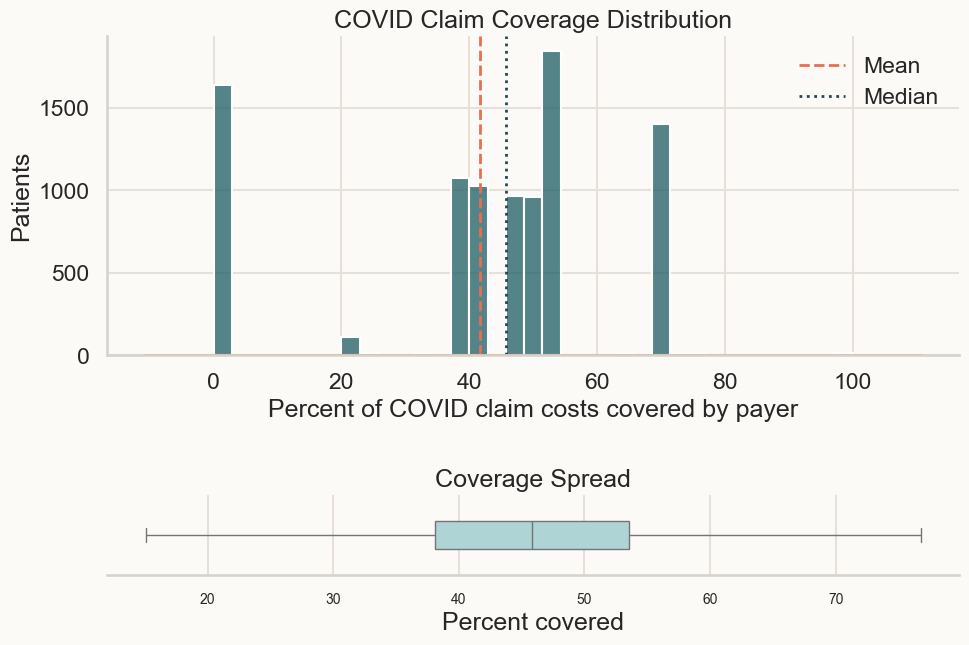

In [20]:

def plot_distribution_with_spread(cohort: pd.DataFrame):
    fig = plt.figure(figsize=(11, 7))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[4, 1], hspace=0.7)

    # Main figure
    ax1 = fig.add_subplot(gs[0])
    sns.histplot(
        cohort["covid_coverage_pct"],
        bins=35,
        color="#1D5C63",
        edgecolor="white",
        ax=ax1,
    )

    axes_mean = cohort["covid_coverage_pct"].mean()
    axes_median = cohort["covid_coverage_pct"].median()

    ax1.axvline(axes_mean, color="#E76F51", linestyle="--", linewidth=2, label="Mean")
    ax1.axvline(axes_median, color="#264653", linestyle=":", linewidth=2, label="Median")

    sns.kdeplot(
        cohort["covid_coverage_pct"],
        color="#E76F51",
        linewidth=2,
        ax=ax1,
    )

    ax1.set_title("Distribution of COVID-Related Insurance Coverage")
    ax1.set_xlabel("Percent of COVID claim costs covered by payer")
    ax1.set_ylabel("Patients")
    ax1.legend(frameon=False)

    ax2 = fig.add_subplot(gs[1])
    sns.boxplot(
        x=cohort["covid_coverage_pct"],
        color="#A8DADC",
        width=0.35,
        showfliers=False,
        ax=ax2,
    )

    ax2.set_title("Spread of COVID-Related Insurance Coverage")
    ax2.set_xlabel("Percent covered")
    ax2.set_yticks([])
    ax2.tick_params(axis="x", labelsize=10)
    ax2.spines["left"].set_visible(False)

    plt.show()
    #return fig

plot_distribution_with_spread(cohort)

### Insurance Coverage by Race

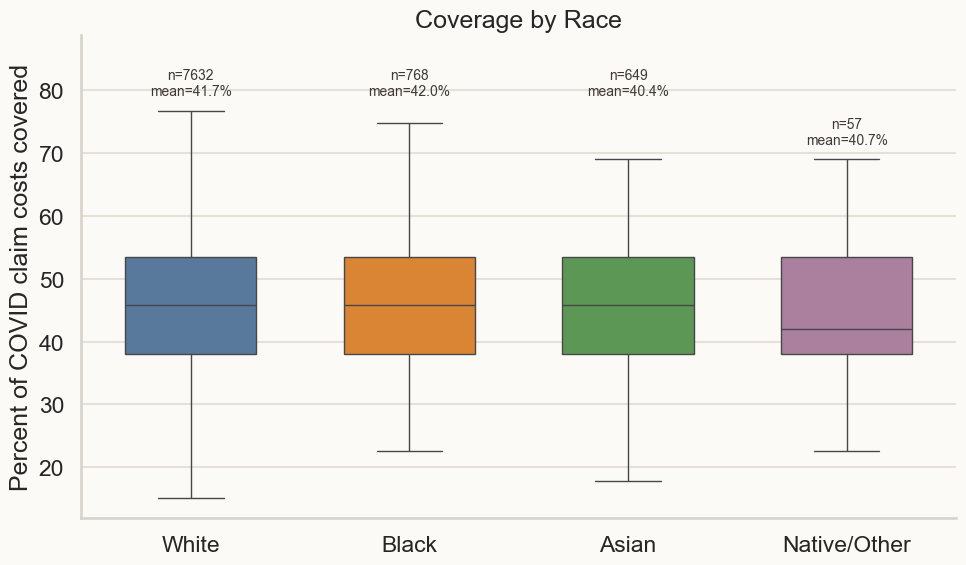

In [19]:
def plot_by_race(cohort: pd.DataFrame, race_stats: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(
        data=cohort,
        x="race_group",
        y="covid_coverage_pct",
        hue="race_group",
        order=RACE_ORDER,
        palette=RACE_COLORS,
        legend=False,
        showfliers=False,
        width=0.6,
        ax=ax,
    )

    ax.set_title("COVID-Related Insurance Coverage by Race")
    ax.set_xlabel("")
    ax.set_ylabel("Percent of COVID claim costs covered")

    # Compute an upper position for each race label
    upper_positions = {}
    for race in RACE_ORDER:
        vals = cohort.loc[cohort["race_group"] == race, "covid_coverage_pct"].dropna()
        if len(vals) == 0:
            continue

        q1 = vals.quantile(0.25)
        q3 = vals.quantile(0.75)
        iqr = q3 - q1
        upper_whisker = min(vals.max(), q3 + 1.5 * iqr)
        upper_positions[race] = upper_whisker

    # Add some headroom so annotations do not collide with the plot top
    if upper_positions:
        y_max = max(upper_positions.values())
        ax.set_ylim(top=y_max + 12)   # adjust 12 if you want more/less space

    # Place text slightly above each group's upper whisker
    for idx, race in enumerate(RACE_ORDER):
        n = race_stats.loc[race_stats["race_group"] == race, "n"]
        mean = race_stats.loc[race_stats["race_group"] == race, "mean_coverage"]

        if not n.empty and race in upper_positions:
            ax.text(
                idx,
                upper_positions[race] + 2,   # small offset above box/whisker
                f"n={int(n.iloc[0])}\nmean={mean.iloc[0]:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10,
                color="#3F3A34",
            )

    fig.tight_layout()
    plt.show()
    #return fig

plot_by_race(cohort, tables['race_stats'])

### Insurance Coverage by County

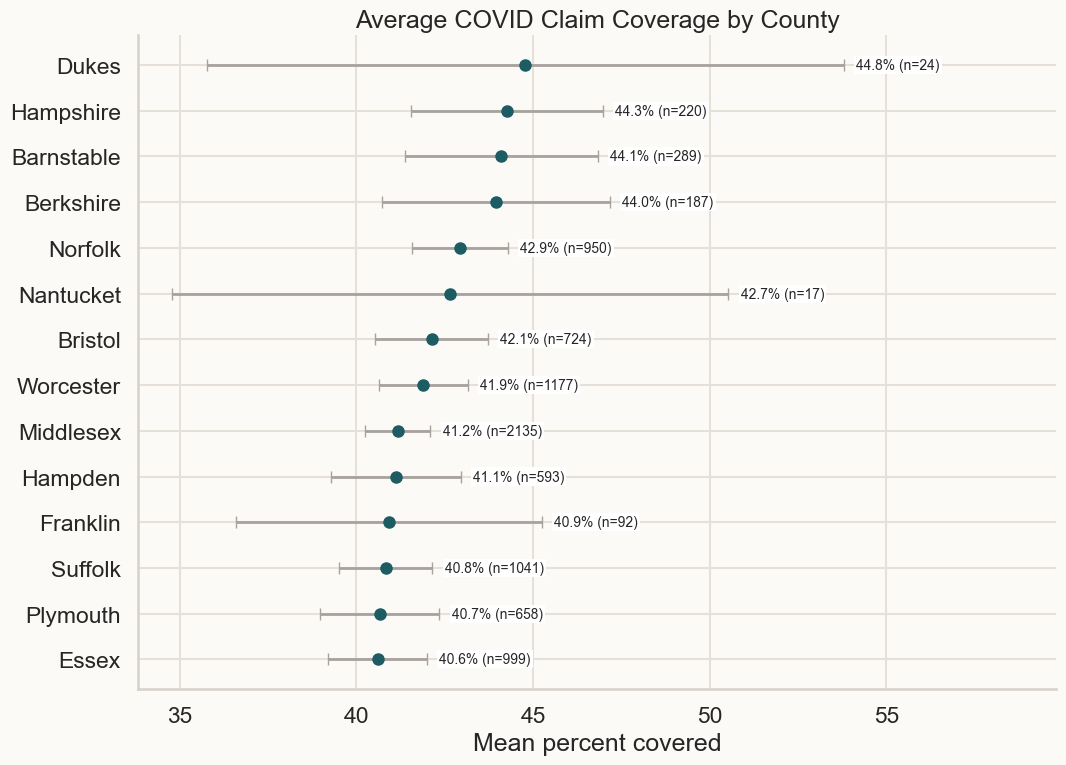

In [ ]:
def plot_by_county(county_stats: pd.DataFrame):
    ordered = county_stats.sort_values("mean_coverage", ascending=True)
    fig, ax = plt.subplots(figsize=(11, 8))

    ax.errorbar(
        ordered["mean_coverage"],
        ordered["county"],
        xerr=np.vstack(
            [
                ordered["mean_coverage"] - ordered["ci_low"],
                ordered["ci_high"] - ordered["mean_coverage"],
            ]
        ),
        fmt="o",
        color="#1D5C63",
        ecolor="#A8A29E",
        elinewidth=2,
        capsize=4,
        markersize=8,
    )

    for _, row in ordered.iterrows():
        label_x = row["ci_high"] + 0.35
        ax.text(
            label_x,
            row["county"],
            f"{row['mean_coverage']:.1f}% (n={int(row['n'])})",
            va="center",
            ha="left",
            fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5),
        )
        
    ax.set_xlim(right=ordered["ci_high"].max() + 6)

    ax.set_title("Average COVID-Related Insurance Coverage by County")
    ax.set_xlabel("Mean percent covered")
    ax.set_ylabel("")

    fig.tight_layout()
    plt.show()
    # return fig

plot_by_county(tables['county_stats'])

### County-Level Coverage Gaps by Race

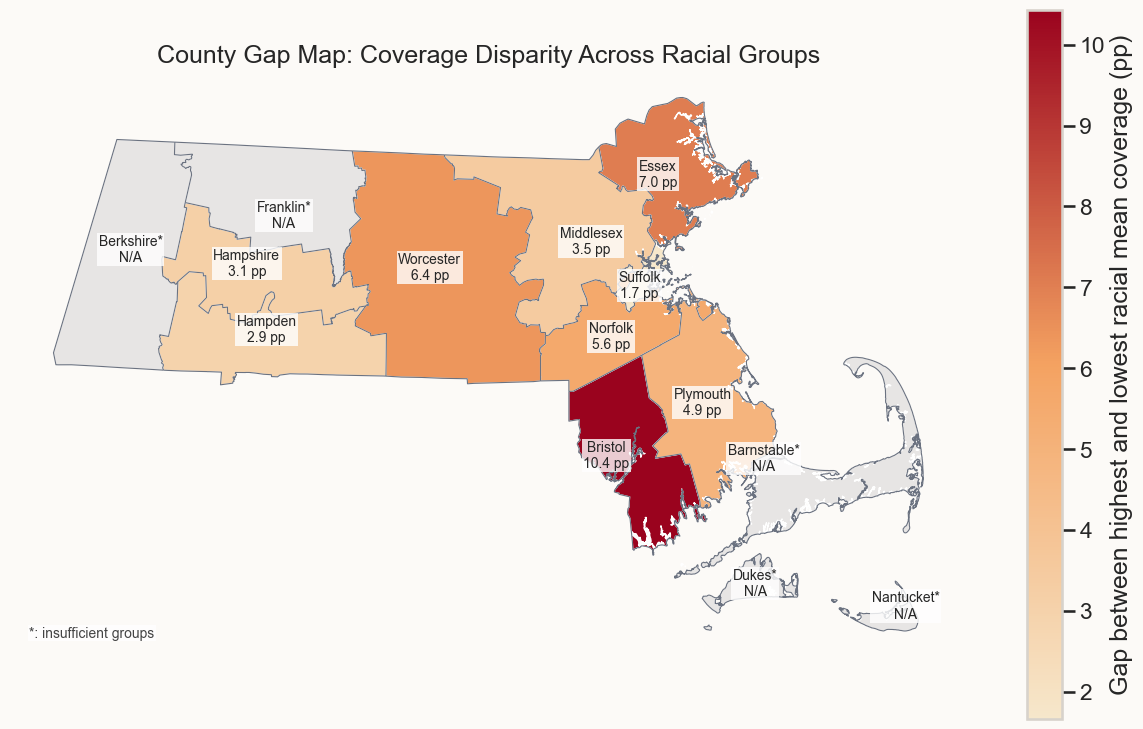

In [22]:
import geopandas as gpd


def plot_gap_map_shapefile(gap_table: pd.DataFrame):
    counties = gpd.read_file("../counties/COUNTIESSURVEY_POLYM.shp")
    county_lines = gpd.read_file("../counties/COUNTIESSURVEY_ARC_GENCOAST.shp")

    county_col = "COUNTY"

    counties = counties[[county_col, "geometry"]].copy()
    counties = counties.rename(columns={county_col: "county"})
    counties["county"] = (
        counties["county"]
        .astype(str)
        .str.replace(" County", "", regex=False)
        .str.strip()
        .str.title()
    )

    gap = gap_table.copy()
    gap["county"] = gap["county"].astype(str).str.strip().str.title()

    map_df = counties.merge(
        gap[["county", "racial_gap_pct_points", "eligible_racial_groups"]],
        on="county",
        how="left",
    )

    eligible = map_df["eligible_racial_groups"].fillna(0) >= 2

    fig, ax = plt.subplots(figsize=(12.5, 10))

    map_df[eligible].plot(
        column="racial_gap_pct_points",
        cmap=GAP_CMAP,
        linewidth=0.8,
        edgecolor="white",
        legend=True,
        legend_kwds={
            "label": "Gap between highest and lowest racial mean coverage (pp)",
            "shrink": 0.75,
        },
        ax=ax,
    )

    if (~eligible).any():
        map_df[~eligible].plot(
            color="#E7E5E4",
            linewidth=0.8,
            edgecolor="white",
            ax=ax,
        )

    county_lines.plot(ax=ax, color="#6B7280", linewidth=0.8)

    label_points = map_df.representative_point()
    for (_, row), pt in zip(map_df.iterrows(), label_points):
        is_eligible = (
            pd.notna(row["racial_gap_pct_points"])
            and row["eligible_racial_groups"] >= 2
        )

        county_name = row["county"] if is_eligible else f"{row['county']}*"
        gap_text = f"{row['racial_gap_pct_points']:.1f} pp" if is_eligible else "N/A"

        ax.text(
            pt.x,
            pt.y,
            f"{county_name}\n{gap_text}",
            ha="center",
            va="center",
            fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.1),
        )

    # Side note
    ax.text(
        0.02, 0.03,
        "*: insufficient groups",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10,
        color="#444",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.0),
    )

    ax.set_title("County-Level Gap Between Highest- and Lowest-Coverage Racial Groups")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    #return fig

plot_gap_map_shapefile(tables["gap_table"])

### Insurance Coverage by Race and County

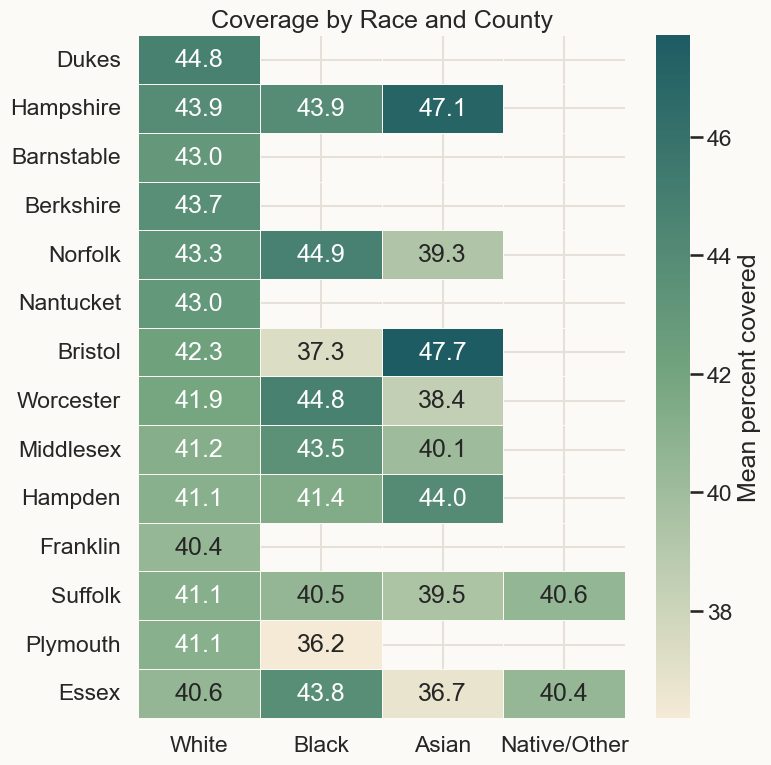

In [23]:
def plot_race_county_heatmap(county_race_stats: pd.DataFrame, county_stats: pd.DataFrame):
    ordered_counties = county_stats.sort_values("mean_coverage", ascending=False)["county"].tolist()
    heatmap_data = county_race_stats.copy()
    heatmap_data.loc[heatmap_data["n"] < 10, "mean_coverage"] = np.nan
    pivot = (
        heatmap_data.pivot(index="county", columns="race_group", values="mean_coverage")
        .reindex(index=ordered_counties, columns=RACE_ORDER)
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap=HEATMAP_CMAP,
        linewidths=0.5,
        linecolor="#FCFAF7",
        cbar_kws={"label": "Mean percent covered"},
        ax=ax,
    )
    ax.set_title("COVID-Related Insurance Coverage by Race and County")
    ax.set_xlabel("")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()
    # return fig

plot_race_county_heatmap(tables['county_race_stats'], tables['county_stats'])


### Mortality by Insurance Coverage Quintile

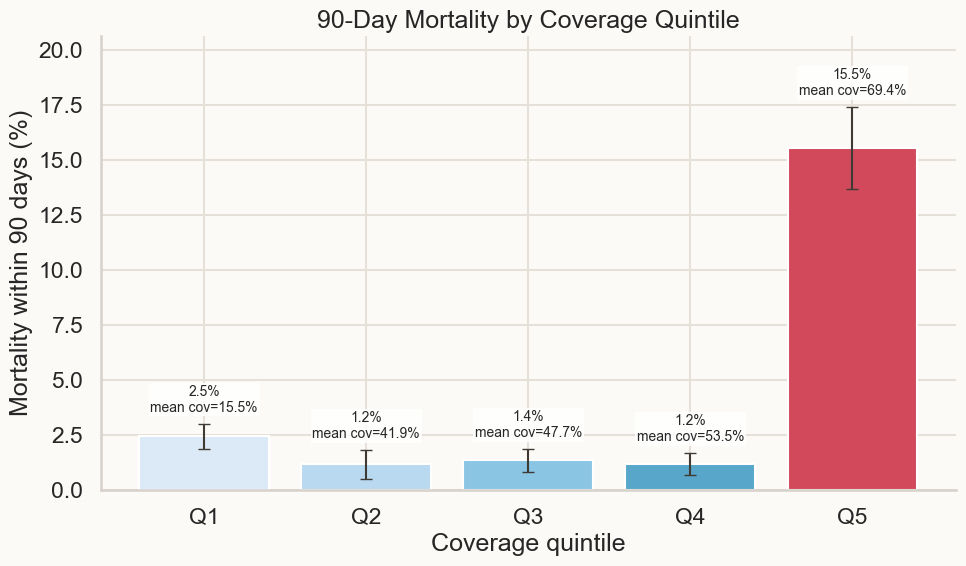

In [25]:
def plot_mortality_quintiles(mortality_quintiles: pd.DataFrame):
    ordered = mortality_quintiles.sort_values("coverage_quintile_num")
    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(
        ordered["coverage_quintile"],
        ordered["mortality_rate_pct"],
        color=["#DCEAF7", "#B8D9F0", "#8AC6E3", "#58A6C9", "#D1495B"],
    )

    ax.errorbar(
        ordered["coverage_quintile"],
        ordered["mortality_rate_pct"],
        yerr=np.vstack(
            [
                ordered["mortality_rate_pct"] - ordered["ci_low_pct"],
                ordered["ci_high_pct"] - ordered["mortality_rate_pct"],
            ]
        ),
        fmt="none",
        ecolor="#3F3A34",
        elinewidth=1.5,
        capsize=4,
    )

    y_top = ordered["ci_high_pct"].max() + 3.2
    ax.set_ylim(0, y_top)

    for bar, (_, row) in zip(bars, ordered.iterrows()):
        label_y = row["ci_high_pct"] + 0.4
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_y,
            f"{row['mortality_rate_pct']:.1f}%\nmean cov={row['mean_coverage']:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.2),
        )

    ax.set_title("90-Day Mortality by Insurance Coverage Quintile")
    ax.set_xlabel("Coverage quintile")
    ax.set_ylabel("Mortality within 90 days (%)")

    fig.tight_layout()
    plt.show()
    # return fig

plot_mortality_quintiles(tables['mortality_quintiles'])

### Coverage, Comorbidity Burden, and Mortality

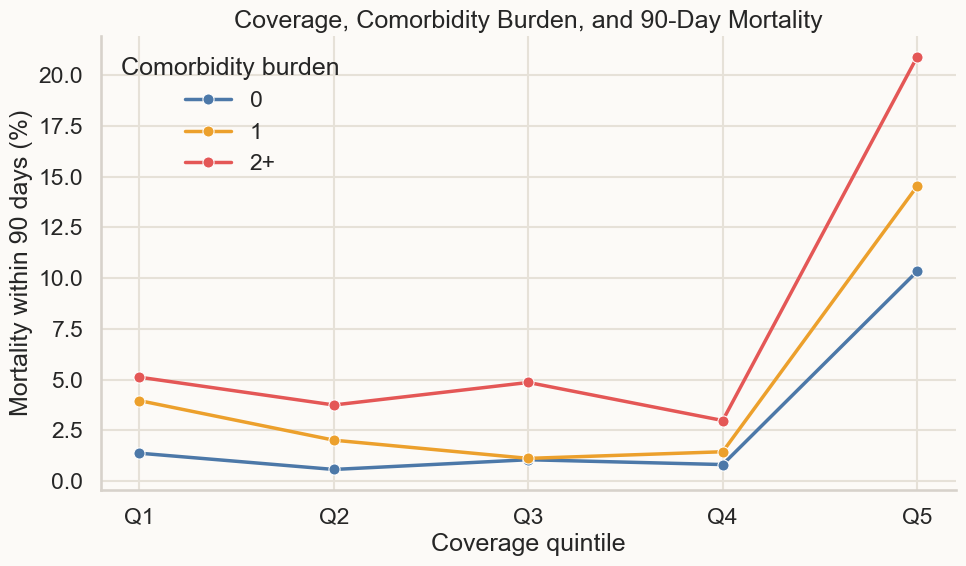

In [26]:
def plot_comorbidity_interaction(burden_quintiles: pd.DataFrame):
    ordered = burden_quintiles.sort_values(["comorbidity_burden", "coverage_quintile_num"])
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=ordered,
        x="coverage_quintile",
        y="mortality_rate_pct",
        hue="comorbidity_burden",
        hue_order=BURDEN_ORDER,
        palette=BURDEN_COLORS,
        marker="o",
        linewidth=2.5,
        markersize=8,
        ax=ax,
    )
    ax.set_title("90-Day Mortality by Insurance Coverage and Comorbidity Burden")
    ax.set_xlabel("Coverage quintile")
    ax.set_ylabel("Mortality within 90 days (%)")
    ax.legend(title="Comorbidity burden", frameon=False)
    fig.tight_layout()
    plt.show()
    # return fig

plot_comorbidity_interaction(tables['burden_quintiles'])


## Summary Helper

This helper builds the inline markdown summary after the cohort and tables are computed.

In [13]:
def build_summary_markdown(
    cohort: pd.DataFrame,
    tables: dict[str, pd.DataFrame],
    model_tables: dict[str, pd.DataFrame],
):
    coverage = tables["summary_stats"].set_index("metric")["value"]
    race_stats = tables["race_stats"]
    county_stats = tables["county_stats"]
    gap_table = tables["gap_table"]
    mortality_quintiles = tables["mortality_quintiles"].sort_values("coverage_quintile_num")
    burden_quintiles = tables["burden_quintiles"]
    interaction_or = model_tables["interaction_or"]

    large_counties = county_stats[county_stats["n"] >= 100].copy()
    highest_large = large_counties.sort_values("mean_coverage", ascending=False).iloc[0]
    lowest_large = large_counties.sort_values("mean_coverage", ascending=True).iloc[0]
    top_gap = gap_table.iloc[0]

    highest_mort = mortality_quintiles.iloc[-1]
    lowest_mort = mortality_quintiles.iloc[0]

    burden_high = (
        burden_quintiles[burden_quintiles["coverage_quintile"] == "Q5"]
        .sort_values("comorbidity_burden")
        .set_index("comorbidity_burden")
    )
    burden_q5_zero = float(burden_high.loc["0", "mortality_rate_pct"])
    burden_q5_two_plus = float(burden_high.loc["2+", "mortality_rate_pct"])

    summary_lines = [
        "# COVID Insurance Coverage Analysis",
        "",
        "## Cohort",
        f"- COVID-positive patients with claim-linked test encounters: {len(cohort):,}.",
        f"- 90-day mortality: {int(cohort['mortality_90d'].sum()):,} patients ({100 * cohort['mortality_90d'].mean():.2f}%).",
        f"- COVID listed as cause of death: {int(cohort['covid_cause_of_death'].sum()):,} patients.",
        "",
        "## Coverage summary",
        f"- Mean coverage: {coverage['mean']:.2f}% of COVID claim costs.",
        f"- Median coverage: {coverage['50%']:.2f}%.",
        f"- Interquartile range: {coverage['25%']:.2f}% to {coverage['75%']:.2f}%.",
        f"- 95th percentile: {coverage['95%']:.2f}%.",
        "",
        "## Race",
        f"- Highest mean coverage: {race_stats.iloc[0]['race_group']} at {race_stats.iloc[0]['mean_coverage']:.2f}%.",
        f"- Lowest mean coverage: {race_stats.iloc[-1]['race_group']} at {race_stats.iloc[-1]['mean_coverage']:.2f}%.",
        f"- Overall racial spread is modest: {race_stats['mean_coverage'].max() - race_stats['mean_coverage'].min():.2f} percentage points.",
        "",
        "## Geography",
        f"- Highest average coverage among counties with at least 100 COVID patients: {highest_large['county']} ({highest_large['mean_coverage']:.2f}%, n={int(highest_large['n'])}).",
        f"- Lowest average coverage among counties with at least 100 COVID patients: {lowest_large['county']} ({lowest_large['mean_coverage']:.2f}%, n={int(lowest_large['n'])}).",
        f"- Largest within-county racial gap: {top_gap['county']} at {top_gap['racial_gap_pct_points']:.2f} percentage points ({top_gap['least_insured_group']} to {top_gap['most_insured_group']}).",
        "",
        "## Mortality",
        f"- Lowest-coverage quintile ({lowest_mort['coverage_quintile']}, mean coverage {lowest_mort['mean_coverage']:.1f}%) had {lowest_mort['mortality_rate_pct']:.2f}% mortality.",
        f"- Highest-coverage quintile ({highest_mort['coverage_quintile']}, mean coverage {highest_mort['mean_coverage']:.1f}%) had {highest_mort['mortality_rate_pct']:.2f}% mortality.",
        "- This pattern is descriptive, not causal: higher coverage is strongly linked to the most intensive and expensive COVID care in this dataset.",
        "",
        "## Comorbidity interaction",
        f"- In the highest-coverage quintile, mortality rose from {burden_q5_zero:.2f}% with no tracked comorbidities to {burden_q5_two_plus:.2f}% with 2+ comorbidities.",
        f"- Interaction model odds ratio for a 10-point coverage increase with burden 0: {interaction_or.iloc[0]['odds_ratio']:.2f} (95% CI {interaction_or.iloc[0]['ci_low']:.2f}-{interaction_or.iloc[0]['ci_high']:.2f}).",
        f"- Interaction model odds ratio for a 10-point coverage increase with burden 2+: {interaction_or.iloc[2]['odds_ratio']:.2f} (95% CI {interaction_or.iloc[2]['ci_low']:.2f}-{interaction_or.iloc[2]['ci_high']:.2f}).",
    ]
    return "\n".join(summary_lines)


In [14]:
summary_md = build_summary_markdown(cohort, tables, model_tables)

In [15]:
display(Markdown(summary_md))


# COVID Insurance Coverage Analysis

## Cohort
- COVID-positive patients with claim-linked test encounters: 9,106.
- 90-day mortality: 357 patients (3.92%).
- COVID listed as cause of death: 345 patients.

## Coverage summary
- Mean coverage: 41.62% of COVID claim costs.
- Median coverage: 45.80%.
- Interquartile range: 38.06% to 53.55%.
- 95th percentile: 69.03%.

## Race
- Highest mean coverage: Black at 42.02%.
- Lowest mean coverage: Asian at 40.36%.
- Overall racial spread is modest: 1.65 percentage points.

## Geography
- Highest average coverage among counties with at least 100 COVID patients: Hampshire (44.26%, n=220).
- Lowest average coverage among counties with at least 100 COVID patients: Essex (40.60%, n=999).
- Largest within-county racial gap: Bristol at 10.44 percentage points (Black to Asian).

## Mortality
- Lowest-coverage quintile (Q1, mean coverage 15.5%) had 2.45% mortality.
- Highest-coverage quintile (Q5, mean coverage 69.4%) had 15.55% mortality.
- This pattern is descriptive, not causal: higher coverage is strongly linked to the most intensive and expensive COVID care in this dataset.

## Comorbidity interaction
- In the highest-coverage quintile, mortality rose from 10.34% with no tracked comorbidities to 20.90% with 2+ comorbidities.
- Interaction model odds ratio for a 10-point coverage increase with burden 0: 1.03 (95% CI 0.93-1.14).
- Interaction model odds ratio for a 10-point coverage increase with burden 2+: 1.10 (95% CI 0.99-1.22).

In [16]:
display(Markdown('## Key Tables'))
display(Markdown('### Cohort overview'))
display(tables['cohort_overview'])
display(Markdown('### Overall race distribution'))
display(tables['overall_race_distribution'])
display(Markdown('### County patient counts'))
display(tables['county_patient_counts'])
display(Markdown('### County demographic summary (patient counts + race percentages)'))
display(tables['county_demographic_summary'])
display(Markdown('### Overall comorbidity distribution'))
display(tables['overall_comorbidity_distribution'])
display(Markdown('### County comorbidity summary (patient counts + comorbidity percentages)'))
display(tables['county_comorbidity_summary'])
display(Markdown('### Coverage summary statistics'))
display(tables['summary_stats'])
display(Markdown('### Coverage by race'))
display(tables['race_stats'])
display(Markdown('### Coverage by county'))
display(tables['county_stats'])
display(Markdown('### County racial coverage gap'))
display(tables['gap_table'])
display(Markdown('### Mortality by coverage quintile'))
display(tables['mortality_quintiles'])
display(Markdown('### Comorbidity summary'))
display(tables['comorbidity_summary'])
display(Markdown('### Odds ratios'))
display(model_tables['mortality_or'])
display(model_tables['interaction_or'])

## Key Tables

### Cohort overview

,covid_positive_patients,mortality_90d_patients,mortality_90d_pct,covid_cause_of_death_patients,mean_age_at_covid,median_age_at_covid
0,9106,357,3.920492,345,41.346313,41.007529


### Overall race distribution

,race_group,patient_count,pct_of_cohort
0,White,7632,83.812871
1,Black,768,8.434000
2,Asian,649,7.127169
3,Native/Other,57,0.625961


...

### Comorbidity summary

,comorbidity,column,patients,prevalence_pct,mean_coverage_pct,mortality_90d_pct
1,Anemia,anemia,1546,16.977817,44.539834,9.184994
6,Arthritis/pain,arthritis_pain,1159,12.727872,44.872628,6.471096
0,Hyperlipidemia,hyperlipidemia,952,10.454645,51.555765,10.609244
2,Asthma,asthma,491,5.392049,39.158713,3.665988
7,Migraine,migraine,412,4.524489,37.955495,3.640777
4,Cancer,cancer,330,3.623984,55.753055,16.969697
8,Seizure disorder,seizure_disorder,218,2.394026,41.458594,7.798165
5,Dementia,dementia,108,1.186031,62.473284,19.444444
3,Heart failure,heart_failure,52,0.571052,52.909728,34.615385


### Odds ratios

,label,terms,scale,log_odds,odds_ratio,ci_low,ci_high
0,Coverage effect,coverage_pct_10,10 percentage points,0.036351,1.037019,0.975714,1.102177
1,Age effect,age_10,10 years,0.619793,1.858543,1.742338,1.982500


,label,terms,scale,log_odds,odds_ratio,ci_low,ci_high
0,"Coverage effect, burden 0",coverage_pct_10,10 percentage points,0.026818,1.027181,0.926439,1.138877
1,"Coverage effect, burden 1",coverage_pct_10 + coverage_pct_10:C(comorbidit...,10 percentage points,-0.002725,0.997279,0.912044,1.090479
2,"Coverage effect, burden 2+",coverage_pct_10 + coverage_pct_10:C(comorbidit...,10 percentage points,0.095492,1.100200,0.992097,1.220083
